In [ ]:
# !wget -O data/mousepancreas.h5ad https://datasets.cellxgene.cziscience.com/49243c50-bf0c-4b10-87f8-55ec9f455399.h5ad

--2026-01-27 20:27:46--  https://datasets.cellxgene.cziscience.com/49243c50-bf0c-4b10-87f8-55ec9f455399.h5ad
Resolving datasets.cellxgene.cziscience.com (datasets.cellxgene.cziscience.com)... 18.239.183.62, 18.239.183.55, 18.239.183.47, ...
Connecting to datasets.cellxgene.cziscience.com (datasets.cellxgene.cziscience.com)|18.239.183.62|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 4072839821 (3.8G) [binary/octet-stream]
Saving to: ‘data/mousepancreas.h5ad’

data/mousepancreas. 100%[===================>]   3.79G  22.8MB/s    in 4m 33s  

2026-01-27 20:32:19 (14.2 MB/s) - ‘data/mousepancreas.h5ad’ saved [4072839821/4072839821]



In [1]:
import scanpy as sc

/orcd/home/002/gokulg/miniforge3/envs/gde/lib/python3.11/site-packages/scanpy/_utils/__init__.py:33: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  from anndata import __version__ as anndata_version
/orcd/home/002/gokulg/miniforge3/envs/gde/lib/python3.11/site-packages/scanpy/__init__.py:24: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):
/orcd/home/002/gokulg/miniforge3/envs/gde/lib/python3.11/site-packages/scanpy/readwrite.py:16: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):


In [8]:
ad = sc.read_h5ad('data/mousepancreas.h5ad')
ad

AnnData object with n_obs × n_vars = 301796 × 30849
    obs: 'batch_integration', 'dataset', 'design', 'cell_cycle_phase', 'ins_high', 'gcg_high', 'sst_high', 'ppy_high', 'cell_filtering', 'strain', 'age', 'cell_type_originalDataset_unified', 'cell_type_originalDataset', 'cell_type_reannotatedIntegrated', 'n_genes', 'mt_frac', 'doublet_score', 'log10_n_counts', 'age_approxDays', 'dataset__design__sample', 'cell_subtype_immune_reannotatedIntegrated', 'cell_subtype_endothelial_reannotatedIntegrated', 'emptyDrops_LogProb_scaled', 'cell_subtype_beta_coarse_reannotatedIntegrated', 'cell_subtype_beta_fine_reannotatedIntegrated', 'GP_1', 'GP_2', 'GP_3', 'GP_4', 'GP_5', 'GP_6', 'GP_7', 'GP_8', 'GP_9', 'GP_10', 'GP_11', 'GP_12', 'GP_13', 'GP_14', 'GP_15', 'GP_16', 'GP_17', 'GP_18', 'GP_19', 'GP_20', 'GP_21', 'GP_22', 'GP_23', 'GP_24', 'GP_25', 'GP_26', 'GP_27', 'assay_ontology_term_id', 'cell_type_ontology_term_id', 'development_stage_ontology_term_id', 'diabetes_model', 'chemical_stress', 'GEO

In [10]:
# follow standard preprocessing and compute PCs

# save raw counts before normalization
ad.layers['counts'] = ad.X.copy()
sc.pp.normalize_total(ad, target_sum=1e4)
sc.pp.log1p(ad)
sc.pp.highly_variable_genes(ad, n_top_genes=500, subset=True)
sc.pp.scale(ad, max_value=10)
sc.tl.pca(ad, svd_solver='arpack')

# save
# ad.write_h5ad('data/mousepancreas.h5ad')

/orcd/home/002/gokulg/miniforge3/envs/gde/lib/python3.11/functools.py:909: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)
/orcd/home/002/gokulg/miniforge3/envs/gde/lib/python3.11/site-packages/scanpy/preprocessing/_pca/__init__.py:243: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  Version(ad.__version__) < Version("0.9")


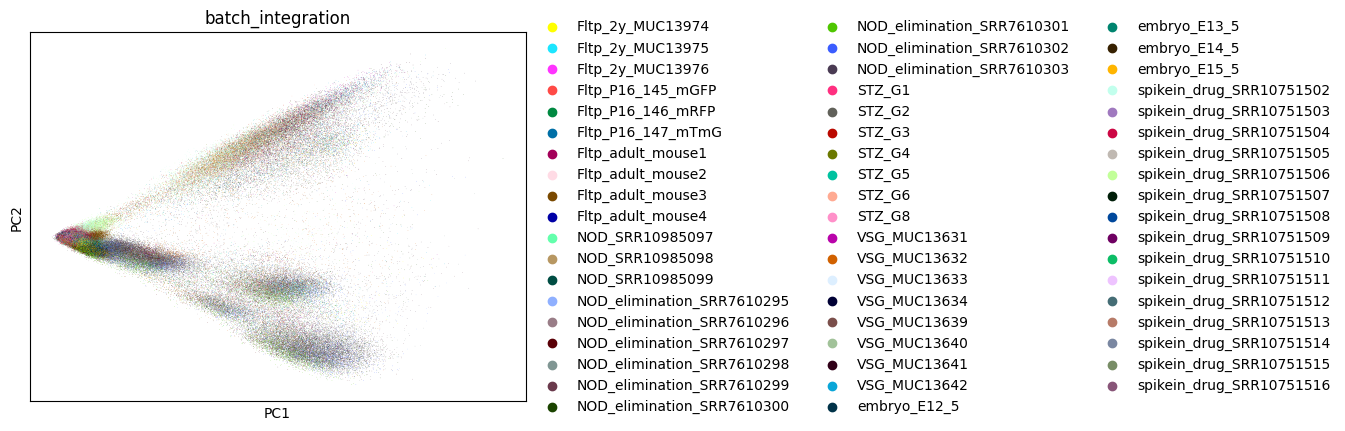

In [11]:
sc.pl.pca(ad, color='batch_integration')

In [22]:
ad.write('data/mousepancreas_processed.h5ad')